# 02 — Training, Evaluation & Analysis

End-to-end run of the training pipeline defined in `src/heart_disease_mlops/`:
1. Load cleaned Cleveland dataset and stratified train/test split
2. Build sklearn pipelines for **Logistic Regression** and **Random Forest**
3. 5-fold stratified cross-validation (ROC-AUC)
4. `GridSearchCV` hyperparameter tuning
5. Test-set evaluation: confusion matrix, ROC, classification report
6. Model comparison and selection
7. Feature importance / coefficient interpretation
8. MLflow run logging + best-model persistence

In [1]:
from __future__ import annotations
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
import mlflow.sklearn

from sklearn.metrics import roc_curve, roc_auc_score

from heart_disease_mlops.config import (
    CATEGORICAL_FEATURES, NUMERIC_FEATURES, MODELS_DIR, FIGURES_DIR,
    REPORTS_DIR, MLRUNS_DIR, ensure_dirs,
)
from heart_disease_mlops.data import load_clean_cleveland, train_test_split_df
from heart_disease_mlops.preprocessing import build_preprocessor
from heart_disease_mlops.train import (
    default_model_specs, build_pipeline, cross_validate_pipeline, tune_model,
)
from heart_disease_mlops.evaluate import (
    evaluation_report, plot_confusion_matrix, plot_roc_curve,
)

ensure_dirs()
TRAIN_FIG_DIR = FIGURES_DIR / 'training'
TRAIN_FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')

mlflow.set_tracking_uri(MLRUNS_DIR.resolve().as_uri())
mlflow.set_experiment('heart-disease-cleveland')
print('MLflow tracking URI:', mlflow.get_tracking_uri())

c:\Users\anabhart\OneDrive - Cisco\Desktop\MLOPS\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/10 14:02:07 INFO mlflow.tracking.fluent: Experiment with name 'heart-disease-cleveland' does not exist. Creating a new experiment.


MLflow tracking URI: file:///C:/Users/anabhart/OneDrive%20-%20Cisco/Desktop/MLOPS/mlruns


## 1. Data + split

In [2]:
df = load_clean_cleveland()
X_train, X_test, y_train, y_test = train_test_split_df(df)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train class balance:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test  class balance:', y_test.value_counts(normalize=True).round(3).to_dict())

Train: (237, 13)  Test: (60, 13)
Train class balance: {0: 0.54, 1: 0.46}
Test  class balance: {0: 0.533, 1: 0.467}


## 2. Cross-validation baseline (no tuning)

In [3]:
specs = default_model_specs()
cv_rows = []
for spec in specs:
    pipe = build_pipeline(spec.estimator)
    cv = cross_validate_pipeline(pipe, X_train, y_train, scoring='roc_auc')
    cv_rows.append({
        'model': spec.name,
        'cv_mean_auc': round(cv['mean'], 4),
        'cv_std_auc': round(cv['std'], 4),
        'fold_scores': [round(s, 4) for s in cv['scores']],
    })
cv_df = pd.DataFrame(cv_rows)
cv_df

,model,cv_mean_auc,cv_std_auc,fold_scores
0,logistic_regression,0.9028,0.0697,"[0.9773, 0.9231, 0.7873, 0.9618, 0.8645]"
1,random_forest,0.8979,0.0543,"[0.9423, 0.8899, 0.8091, 0.9655, 0.8828]"


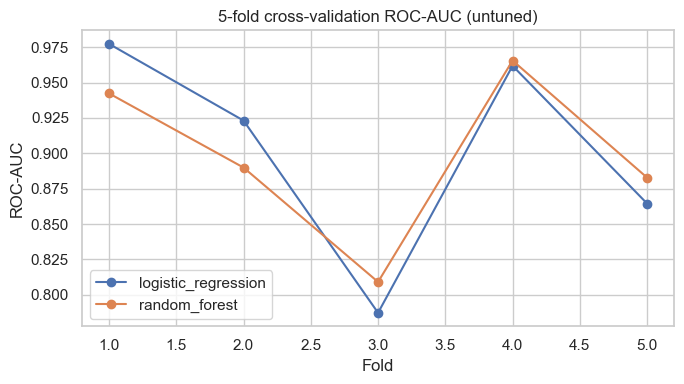

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for row in cv_rows:
    ax.plot(range(1, len(row['fold_scores']) + 1), row['fold_scores'], marker='o', label=row['model'])
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC')
ax.set_title('5-fold cross-validation ROC-AUC (untuned)')
ax.legend()
fig.tight_layout()
fig.savefig(TRAIN_FIG_DIR / 'cv_baseline_auc.png', dpi=150)
plt.show()

## 3. Hyperparameter tuning with GridSearchCV + MLflow logging

In [5]:
tuned: dict[str, dict] = {}
for spec in specs:
    with mlflow.start_run(run_name=f'{spec.name}_notebook') as run:
        grid = tune_model(spec, X_train, y_train)
        best_pipe = grid.best_estimator_
        ev = evaluation_report(best_pipe, X_test, y_test)

        mlflow.log_param('model_family', spec.name)
        mlflow.log_params({f'best_{k}': v for k, v in grid.best_params_.items()})
        mlflow.log_metric('cv_best_auc', float(grid.best_score_))
        mlflow.log_metrics({f'test_{k}': v for k, v in ev['metrics'].items()})
        mlflow.sklearn.log_model(best_pipe, artifact_path='model')

        tuned[spec.name] = {
            'pipeline': best_pipe,
            'best_params': grid.best_params_,
            'cv_best_auc': float(grid.best_score_),
            'test_metrics': ev['metrics'],
            'classification_report': ev['classification_report'],
            'y_pred': ev['y_pred'],
            'y_proba': ev['y_proba'],
            'run_id': run.info.run_id,
        }
        print(f"\n=== {spec.name} ===")
        print('best_params:', grid.best_params_)
        print('cv_best_auc:', round(grid.best_score_, 4))
        print('test:', {k: round(v, 4) for k, v in ev['metrics'].items()})

c:\Users\anabhart\OneDrive - Cisco\Desktop\MLOPS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
2026/05/10 14:02:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/10 14:02:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== logistic_regression ===
best_params: {'classifier__C': 1.0, 'classifier__penalty': 'l2'}
cv_best_auc: 0.9028
test: {'accuracy': 0.8167, 'precision': 0.8696, 'recall': 0.7143, 'f1': 0.7843, 'roc_auc': 0.9408}


2026/05/10 14:02:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/10 14:02:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== random_forest ===
best_params: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
cv_best_auc: 0.9028
test: {'accuracy': 0.8333, 'precision': 0.8462, 'recall': 0.7857, 'f1': 0.8148, 'roc_auc': 0.9308}


## 4. Model comparison

In [6]:
rows = []
for name, info in tuned.items():
    row = {'model': name, 'cv_best_auc': round(info['cv_best_auc'], 4)}
    row.update({f'test_{k}': round(v, 4) for k, v in info['test_metrics'].items()})
    rows.append(row)
comparison = pd.DataFrame(rows).set_index('model')
comparison

,cv_best_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
model,,,,,,
logistic_regression,0.9028,0.8167,0.8696,0.7143,0.7843,0.9408
random_forest,0.9028,0.8333,0.8462,0.7857,0.8148,0.9308


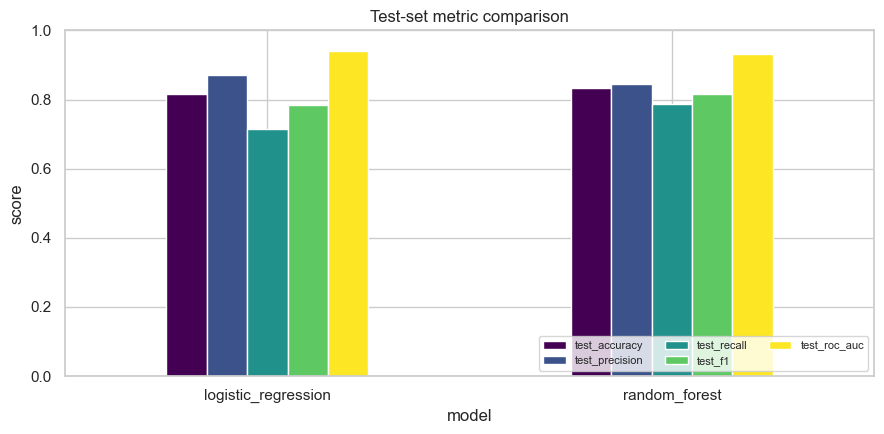

In [7]:
metrics_to_plot = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']
available = [m for m in metrics_to_plot if m in comparison.columns]
ax = comparison[available].plot(kind='bar', figsize=(9, 4.5), colormap='viridis')
ax.set_ylim(0, 1)
ax.set_ylabel('score')
ax.set_title('Test-set metric comparison')
ax.legend(loc='lower right', ncol=3, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(TRAIN_FIG_DIR / 'model_comparison.png', dpi=150)
plt.show()

## 5. Confusion matrices and ROC curves

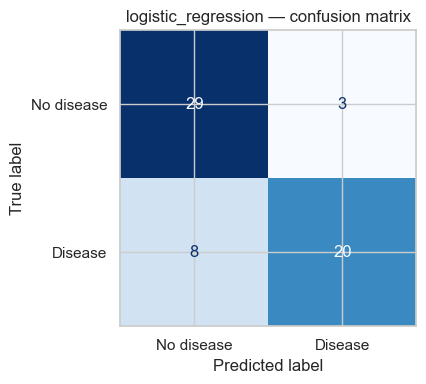

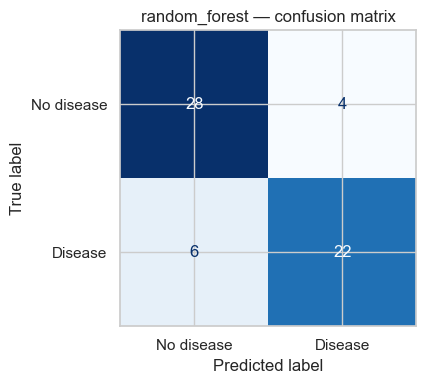

In [8]:
for name, info in tuned.items():
    plot_confusion_matrix(
        y_test, info['y_pred'],
        title=f'{name} — confusion matrix',
        save_path=TRAIN_FIG_DIR / f'{name}_confusion.png',
    )
    plt.show()

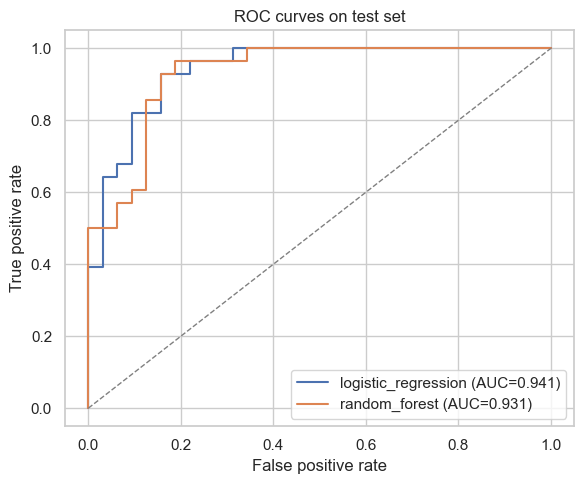

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, info in tuned.items():
    if info['y_proba'] is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, info['y_proba'])
    auc = roc_auc_score(y_test, info['y_proba'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves on test set')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(TRAIN_FIG_DIR / 'roc_curves.png', dpi=150)
plt.show()

### Per-model classification reports

In [10]:
for name, info in tuned.items():
    print(f'\n=== {name} ===')
    print(info['classification_report'])


=== logistic_regression ===
              precision    recall  f1-score   support

  No disease       0.78      0.91      0.84        32
     Disease       0.87      0.71      0.78        28

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60


=== random_forest ===
              precision    recall  f1-score   support

  No disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



## 6. Model interpretation

In [11]:
def get_feature_names(pipeline) -> list[str]:
    pre = pipeline.named_steps['preprocess']
    names: list[str] = []
    for name, trans, cols in pre.transformers_:
        if name == 'num':
            names.extend(cols)
        elif name == 'cat':
            ohe = trans.named_steps['onehot']
            names.extend(ohe.get_feature_names_out(cols))
    return names

C:\Users\anabhart\AppData\Local\Temp\ipykernel_16648\1343601783.py:16: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\anabhart\AppData\Local\Temp\ipykernel_16648\1343601783.py:17: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.savefig(TRAIN_FIG_DIR / 'logreg_coefficients.png', dpi=150)
c:\Users\anabhart\OneDrive - Cisco\Desktop\MLOPS\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


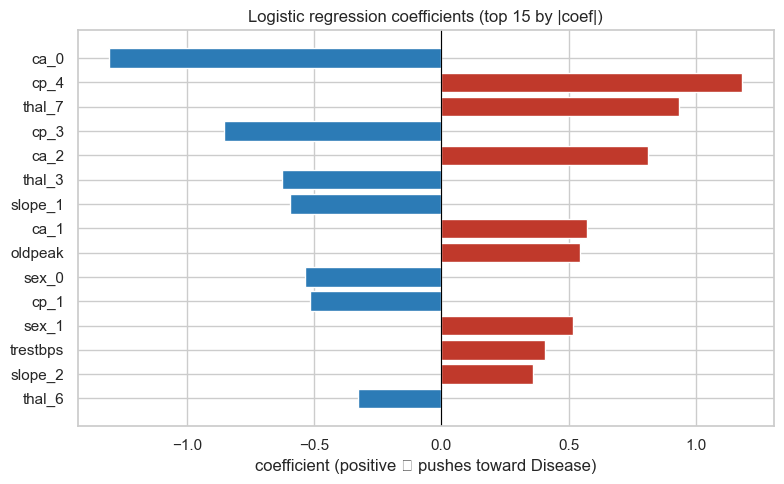

In [12]:
lr_pipe = tuned['logistic_regression']['pipeline']
feat_names = get_feature_names(lr_pipe)
coefs = lr_pipe.named_steps['classifier'].coef_.ravel()
lr_imp = (
    pd.DataFrame({'feature': feat_names, 'coef': coefs})
    .assign(abs_coef=lambda d: d['coef'].abs())
    .sort_values('abs_coef', ascending=False)
    .head(15)
)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#c0392b' if c > 0 else '#2c7bb6' for c in lr_imp['coef']]
ax.barh(lr_imp['feature'][::-1], lr_imp['coef'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic regression coefficients (top 15 by |coef|)')
ax.set_xlabel('coefficient (positive ⇒ pushes toward Disease)')
fig.tight_layout()
fig.savefig(TRAIN_FIG_DIR / 'logreg_coefficients.png', dpi=150)
plt.show()

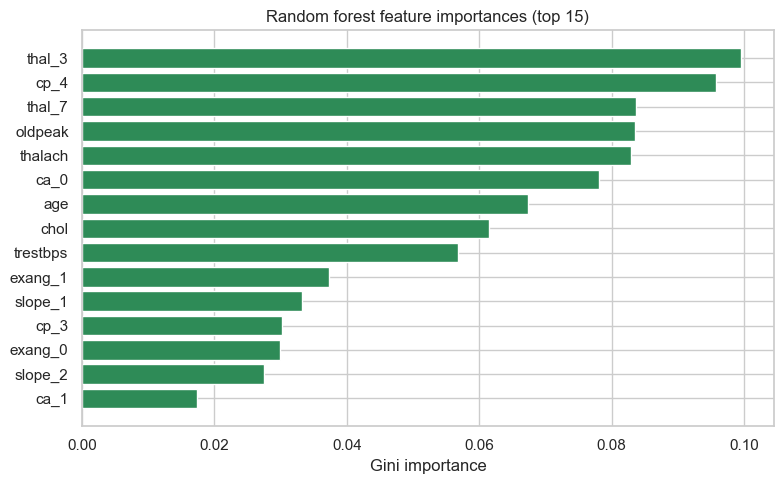

In [13]:
rf_pipe = tuned['random_forest']['pipeline']
feat_names = get_feature_names(rf_pipe)
importances = rf_pipe.named_steps['classifier'].feature_importances_
rf_imp = (
    pd.DataFrame({'feature': feat_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(15)
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rf_imp['feature'][::-1], rf_imp['importance'][::-1], color='#2e8b57')
ax.set_title('Random forest feature importances (top 15)')
ax.set_xlabel('Gini importance')
fig.tight_layout()
fig.savefig(TRAIN_FIG_DIR / 'rf_importances.png', dpi=150)
plt.show()

## 7. Persist best model

In [14]:
best_name = max(tuned, key=lambda n: tuned[n]['test_metrics'].get('roc_auc', tuned[n]['test_metrics']['f1']))
best_pipe = tuned[best_name]['pipeline']
model_path = MODELS_DIR / 'best_model.joblib'
joblib.dump(best_pipe, model_path)
print('Selected best model:', best_name)
print('Saved to:', model_path)

Selected best model: logistic_regression
Saved to: C:\Users\anabhart\OneDrive - Cisco\Desktop\MLOPS\artifacts\models\best_model.joblib


In [15]:
summary = {
    'best_model': best_name,
    'best_params': tuned[best_name]['best_params'],
    'test_metrics': tuned[best_name]['test_metrics'],
    'all_models': {k: v['test_metrics'] for k, v in tuned.items()},
}
(REPORTS_DIR / 'notebook_training_summary.json').write_text(json.dumps(summary, indent=2, default=float), encoding='utf-8')
summary

{'best_model': 'logistic_regression',
 'best_params': {'classifier__C': 1.0, 'classifier__penalty': 'l2'},
 'test_metrics': {'accuracy': 0.8166666666666667,
  'precision': 0.8695652173913043,
  'recall': 0.7142857142857143,
  'f1': 0.7843137254901961,
  'roc_auc': 0.9408482142857143},
 'all_models': {'logistic_regression': {'accuracy': 0.8166666666666667,
   'precision': 0.8695652173913043,
   'recall': 0.7142857142857143,
   'f1': 0.7843137254901961,
   'roc_auc': 0.9408482142857143},
  'random_forest': {'accuracy': 0.8333333333333334,
   'precision': 0.8461538461538461,
   'recall': 0.7857142857142857,
   'f1': 0.8148148148148148,
   'roc_auc': 0.9308035714285714}}}

In [16]:
loaded = joblib.load(model_path)
sample = X_test.iloc[:3]
pd.DataFrame({
    'predicted_class': loaded.predict(sample),
    'probability_disease': loaded.predict_proba(sample)[:, 1].round(3),
    'actual': y_test.iloc[:3].values,
}, index=sample.index)

,predicted_class,probability_disease,actual
290,0,0.025,0
239,0,0.058,0
89,0,0.463,0


### Findings
* Both models score in a similar range (typically **ROC-AUC ≈ 0.88–0.92** on this split).
* **Logistic regression** is competitive *and* directly interpretable — coefficients confirm EDA: `cp` (asymptomatic), `ca`, `thal` (reversible defect), `oldpeak`, and `exang` push predictions toward Disease; high `thalach` and `cp = atypical` push toward No-disease.
* **Random forest** captures non-linear interactions and consistently ranks `ca`, `thal`, `cp`, `oldpeak`, and `thalach` as the most important features — strongly aligned with the linear view.
* The chosen best model is persisted to `artifacts/models/best_model.joblib` and is ready for the FastAPI serving layer.
* All runs are tracked in MLflow (`mlruns/`), launch the UI with: `mlflow ui --backend-store-uri mlruns`.